In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

In [2]:
import os
api_key = os.getenv("GIGA_API_KEY")

In [3]:
llm = llm_01 = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.1,
    profanity_check = False,
    model="GigaChat",
)

In [4]:
msg = HumanMessage(content="Hello world", name="Lance")
messages = [msg]
llm.invoke(messages)

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 13, 'completion_tokens': 10, 'total_tokens': 23, 'precached_prompt_tokens': 0}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': '5a98737b-7ebf-4580-8906-eae88bda72be', 'x-session-id': '39344c8a-744f-497f-a0c4-930229d14947', 'x-client-id': None}, 'finish_reason': 'stop'}, id='5a98737b-7ebf-4580-8906-eae88bda72be')

In [5]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

In [6]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

In [7]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    user_input = state['graph_state'] 
    
    if random.random() < 0.5:
        return "node_2"
        return "node_3"

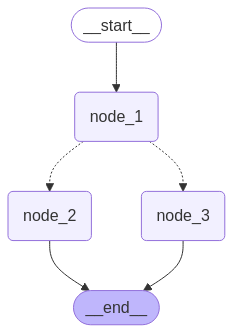

In [8]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Lance. I am happy!'}

=====================================================================================================================

# CHAIN

In [10]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

In [11]:
messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [12]:
llm.invoke(messages)

AIMessage(content='The best places to see orcas (also known as killer whales) in the United States vary depending on your location and preferences. Here are some of the top spots:\n\n### 1. **San Juan Islands, Washington**\n   - **Why it’s great:** This is one of the most popular places for orca watching in the U.S., especially during summer months when they frequent the area. You can often spot them from land at locations such as Lime Kiln Point State Park.\n   - **Best time:** June through September.\n\n### 2. **Monterey Bay, California**\n   - **Why it’s great:** Monterey Bay offers a unique opportunity to see not only orcas but also other marine life including humpback whales, dolphins, and sea otters. It’s an excellent place for boat tours and wildlife viewing.\n   - **Best time:** Year-round, with peak sightings in spring and fall.\n\n### 3. **Gulf of Alaska**\n   - **Why it’s great:** While this isn’t exactly a single destination, the Gulf of Alaska is renowned for its abundance

In [13]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [14]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [15]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'b88c75a1-6337-402c-953c-9ae6642e2bd0',
  'type': 'tool_call'}]

In [16]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

### **Редукторы (Reducers)**  

Теперь у нас есть небольшая проблема!  

Как мы обсуждали ранее, **каждый узел возвращает новое значение** для ключа состояния `messages`.  

Но это новое значение **заменяет** предыдущее значение `messages`.  

### **Как исправить?**  
Чтобы при выполнении графа **сообщения добавлялись**, а не перезаписывались, **нужны редукторы**.  

### **Что такое редукторы?**  
Редукторы — это функции, которые определяют, **как обновляется состояние**.  

- **Если редуктор не указан** → значение **просто заменяется** (перезапись).  
- **Если используется `add_messages`** → новые сообщения **добавляются в конец списка**.  

### **Как использовать `add_messages`?**  
Нужно просто **добавить аннотацию** с этим редуктором в ключ `messages`.  

Это гарантирует, что **все новые сообщения будут добавляться** в список сообщений, а не затирать старые.

In [18]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Встроенное состояние сообщений (MessagesState)

Так как хранение списка сообщений в состоянии графа — очень частый случай, LangGraph уже содержит встроенный MessagesState!

MessagesState определён следующим образом:

Содержит предустановленный ключ messages.
Это список объектов AnyMessage.
Использует редуктор add_messages, чтобы новые сообщения добавлялись, а не перезаписывали старые.
Обычно мы будем использовать MessagesState, так как это короче и удобнее, чем вручную определять TypedDict, как показано ранее.

In [19]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

In [20]:
# Начальное состояние
initial_messages = [
    AIMessage(content="Привет! Как я могу помочь вам?", name="Модель"),
    HumanMessage(content="Я ищу информацию о морской биологии.", name="Ланс")
]

# Новое сообщение для добавления
new_message = AIMessage(content="Конечно, я могу помочь! Что именно вас интересует?", name="Модель")

# Тест
add_messages(initial_messages, new_message)

[AIMessage(content='Привет! Как я могу помочь вам?', additional_kwargs={}, response_metadata={}, name='Модель', id='5b7e62aa-a830-43a8-a3d2-2b772726e359'),
 HumanMessage(content='Я ищу информацию о морской биологии.', additional_kwargs={}, response_metadata={}, name='Ланс', id='10e942b0-b649-4e4e-b81d-3e2d2780469c'),
 AIMessage(content='Конечно, я могу помочь! Что именно вас интересует?', additional_kwargs={}, response_metadata={}, name='Модель', id='5fd5f840-9035-41a8-82e0-0829e0fdcfe2')]

In [23]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

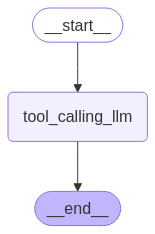

In [24]:
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
messages = graph.invoke({"messages": HumanMessage(content="Привет!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Привет!
================================== Ai Message ==================================

Привет! Что интересного у тебя на уме?


In [26]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (72f3e11d-c637-4877-ab88-6888ddeffb4c)
 Call ID: 72f3e11d-c637-4877-ab88-6888ddeffb4c
  Args:
    a: 2
    b: 3


In [29]:
messages = graph.invoke({"messages": [HumanMessage(content="Multiply 2 and 3")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (797146e5-ed84-40dd-9179-6e70ac802120)
 Call ID: 797146e5-ed84-40dd-9179-6e70ac802120
  Args:
    a: 2
    b: 3


=============================================================================================================================

# Router

# Router (Маршрутизатор)

## Review (Обзор)

Мы построили граф, который использует `messages` в качестве состояния, и чат-модель с привязанными инструментами (tools).

Мы увидели, что граф может:

* Возвращать вызов инструмента (tool call)
* Возвращать ответ на естественном языке

## Goals (Цели)

Мы можем рассматривать это как маршрутизатор (router), где чат-модель выбирает между прямым ответом или вызовом инструмента на основе ввода пользователя.

Это простой пример агента, где LLM управляет потоком управления, либо вызывая инструмент, либо просто отвечая напрямую.

![Screenshot 2024-08-21 at 9.24.09 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac6543c3d4df239a4ed1_router1.png)

Давайте расширим наш граф, чтобы он мог работать с любым из этих выходов!

Для этого мы можем использовать две идеи:

1. Добавить узел, который будет вызывать наш инструмент.
2. Добавить условное ребро, которое будет анализировать выход чат-модели и направлять либо к узлу вызова инструмента, либо завершать работу, если вызов инструмента не требуется.

Мы используем [встроенный `ToolNode`](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=tools+condition#toolnode) и просто передаём список наших инструментов для его инициализации.

Мы используем [встроенный `tools_condition`](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=tools+condition#tools_condition) в качестве нашего условного ребра.

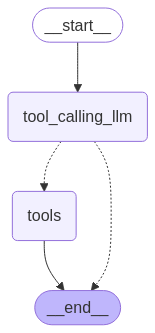

In [33]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
from langchain_core.messages import HumanMessage, SystemMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (4940b748-c218-4c82-990a-f424030e2fb0)
 Call ID: 4940b748-c218-4c82-990a-f424030e2fb0
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


===================================================================================================================

# AGENT

## Review (Обзор)

Мы построили маршрутизатор (router).

* Наша чат-модель будет решать, нужно ли вызывать инструмент, на основе ввода пользователя.
* Мы используем условное ребро, чтобы направить поток к узлу, который вызовет инструмент, или просто завершить выполнение.

![Screenshot 2024-08-21 at 12.44.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0ba0bd34b541c448cc_agent1.png)

## Goals (Цели)

Теперь мы можем расширить это до универсальной архитектуры агента.

В описанном выше маршрутизаторе мы вызывали модель, и если она решала вызвать инструмент, мы возвращали пользователю `ToolMessage`.

Но что, если мы просто передадим этот `ToolMessage` *обратно модели*?

Мы можем позволить ей либо (1) вызвать другой инструмент, либо (2) ответить напрямую.

Это идея, лежащая в основе [ReAct](https://react-lm.github.io/), универсальной архитектуры агента.

* `act` — позволить модели вызывать определённые инструменты.
* `observe` — передать результат работы инструмента обратно модели.
* `reason` — позволить модели анализировать результат инструмента, чтобы решить, что делать дальше (например, вызвать другой инструмент или просто ответить напрямую).

Эта [универсальная архитектура](https://blog.langchain.dev/planning-for-agents/) может быть применена ко многим типам инструментов.

![Screenshot 2024-08-21 at 12.45.43 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0b4a2c1e5e02f3e78b_agent2.png)

In [41]:
def multiply(a: int, b: int) -> int:
    """Умножает a и b.

    Args:
        a: первое целое число
        b: второе целое число
    """
    return a * b

# Это будет инструмент
def add(a: int, b: int) -> int:
    """Складывает a и b.

    Args:
        a: первое целое число
        b: второе целое число
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Делит a на b.

    Args:
        a: первое целое число
        b: второе целое число
    """
    return a / b

tools = [add, multiply, divide]

In [42]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [43]:
# Системное сообщение
sys_msg = SystemMessage(content="Вы помощник, задача которого — выполнять арифметические операции над набором входных данных.")

# Узел
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

Как и раньше, мы используем `MessagesState` и определяем узел `Tools` с нашим списком инструментов.

Узел `Assistant` — это просто наша модель с привязанными инструментами.

Мы создаём граф с узлами `Assistant` и `Tools`.

Добавляем условное ребро `tools_condition`, которое направляет поток либо к `End`, либо к `Tools`, в зависимости от того, вызывает ли `Assistant` инструмент.

Теперь мы добавляем один новый шаг:

Мы соединяем узел `Tools` *обратно* с узлом `Assistant`, создавая цикл.

* После выполнения узла `assistant`, `tools_condition` проверяет, является ли выход модели вызовом инструмента.
* Если это вызов инструмента, поток направляется к узлу `tools`.
* Узел `tools` соединяется обратно с узлом `assistant`.
* Этот цикл продолжается до тех пор, пока модель решает вызывать инструменты.
* Если ответ модели не является вызовом инструмента, поток направляется к `END`, завершая процесс.

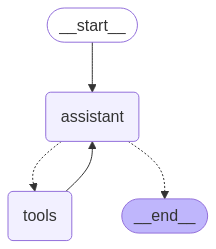

In [44]:
# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [45]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
messages = react_graph.invoke({"messages": messages})

In [46]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (b520d7b2-cb78-4596-9cd6-4c8a841f847d)
 Call ID: b520d7b2-cb78-4596-9cd6-4c8a841f847d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (b1b84422-b1a3-4019-9f6c-38978395ca9c)
 Call ID: b1b84422-b1a3-4019-9f6c-38978395ca9c
  Args:
    a: 7
    b: 1
================================= Tool Message =================================
Name: multiply

7
================================== Ai Message ==================================
Tool Calls:
  divide (ece95d1d-c6f5-4a0d-bcf7-f7c7f515a5e0)
 Call ID: ece95d1d-c6f5-4a0d-bcf7-f7c7f515a5e0
  Args:
    a: 7
    b: 1
======================

==================================================================================================================

# Память агента (Agent Memory)

## Обзор (Review)

Ранее мы создали агента, который может:

* `act` — позволить модели вызывать определённые инструменты.
* `observe` — передать результат работы инструмента обратно модели.
* `reason` — позволить модели анализировать результат инструмента, чтобы решить, что делать дальше (например, вызвать другой инструмент или просто ответить напрямую).

![Screenshot 2024-08-21 at 12.45.32 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab7453080e6802cd1703_agent-memory1.png)

## Цели (Goals)

Теперь мы расширим нашего агента, добавив память.

[Состояние является временным](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220) для одного выполнения графа.

Конечно, это ограничивает нашу возможность вести многоходовые диалоги с перерывами.

Мы можем использовать [сохранение состояния (persistence)](https://langchain-ai.github.io/langgraph/how-tos/persistence/), чтобы решить эту проблему!

LangGraph может использовать **чекпоинтер** для автоматического сохранения состояния графа после каждого шага.

Этот встроенный механизм сохранения состояния предоставляет нам **память**, позволяя LangGraph продолжить работу с последнего обновления состояния.

Одним из самых простых чекпоинтеров для использования является `MemorySaver` — это хранилище "ключ-значение" в памяти для состояния графа.

Всё, что нам нужно сделать, — это просто скомпилировать граф с чекпоинтером, и наш граф получит память!

In [47]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

Когда мы используем память, нам нужно указать `thread_id`.

Этот `thread_id` будет хранить нашу коллекцию состояний графа.

Вот как это выглядит:

* Чекпоинтер записывает состояние на каждом шаге графа.
* Эти чекпоинты сохраняются в потоке (thread).
* Мы можем получить доступ к этому потоку в будущем, используя `thread_id`.

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e0e9f526b41a4ed9e2d28b_agent-memory2.png)

In [48]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Сложи 3 и 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Сложи 3 и 4.
================================== Ai Message ==================================
Tool Calls:
  add (58d9474d-9918-4958-810d-3be931e160f7)
 Call ID: 58d9474d-9918-4958-810d-3be931e160f7
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

Сумма чисел 3 и 4 равна 7.


_________________________________________________
Если мы передаём тот же `thread_id`, то можем продолжить с последнего сохранённого чекпоинта состояния!

В этом случае вышеуказанный диалог сохраняется в потоке (thread).

`HumanMessage`, который мы передаём (`"Умножь это на 2."`), добавляется к предыдущему диалогу.

Таким образом, модель теперь понимает, что `это` относится к `"Сумма 3 и 4 равна 7."`.

In [49]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Сложи 3 и 4.
================================== Ai Message ==================================
Tool Calls:
  add (58d9474d-9918-4958-810d-3be931e160f7)
 Call ID: 58d9474d-9918-4958-810d-3be931e160f7
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

Сумма чисел 3 и 4 равна 7.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (e175a99a-68d7-4d9e-9f91-b2ec138875e0)
 Call ID: e175a99a-68d7-4d9e-9f91-b2ec138875e0
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ===========================